In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegrSSession
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import accuracy_score, recall_score, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import pandas as pd

#### Load dataset

In [ ]:
df=pd.read_excel('./Data/IMT_Classification_Dataset_Reduced_Feature_Set_v10.xlsx')
df.head()

In [3]:
df.Label.unique()
# Filter the DataFrame to exclude rows where Label is 2
filtered_df = df[df['Label'] != 2]

In [4]:
# Drop unnecessary columns and separate features (X) and labels (y)
X = filtered_df.drop(columns=['struct_file_path', 'Label', 'Compound'])
y = filtered_df['Label']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

-----
- Key Reasons for Feature Scaling: Equal Contribution,Improved Convergence Speed, Enhanced Model Performance,Numerical Stability,Interpretability

In [6]:
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

----

### Neural Network 

In [10]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # Define input shape here
    layers.Dense(64, activation='relu',),
    layers.Dense(128, activation='relu',),
    layers.Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


-----

### Training

In [11]:

# Train the model
nn = model.fit(X_train_scaled, y_train, epochs=60, batch_size=20, validation_split=0.2)

# Evaluate the model
y_pred_prob = model.predict(X_test_scaled).flatten()

Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5759 - loss: 0.6787 - val_accuracy: 0.7436 - val_loss: 0.5841
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7883 - loss: 0.5676 - val_accuracy: 0.7949 - val_loss: 0.4942
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8261 - loss: 0.4941 - val_accuracy: 0.8205 - val_loss: 0.4389
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8099 - loss: 0.4698 - val_accuracy: 0.8205 - val_loss: 0.4069
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8301 - loss: 0.4126 - val_accuracy: 0.8205 - val_loss: 0.3899
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8349 - loss: 0.3902 - val_accuracy: 0.8205 - val_loss: 0.3775
Epoch 7/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7920 - loss: 0.4158 - val_accuracy: 0.8205 - val_loss: 0.3596
Epoch 8/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8316 - loss: 0.3608 - val_accuracy: 0.8462 - val_loss: 0.3418
Epoch 9

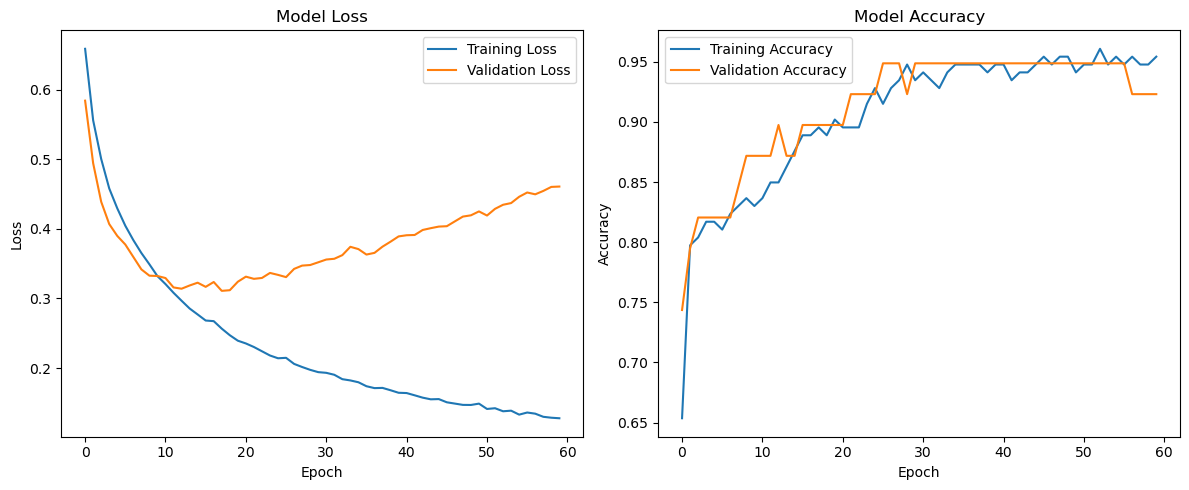

In [14]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(nn.history['loss'], label='Training Loss')
plt.plot(nn.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(nn.history['accuracy'], label='Training Accuracy')
plt.plot(nn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('nn-gap')
plt.show()


### Compare to LogReg

In [ ]:
import pickle
# Load LogReg metrics
with open('logreg_metrics.pkl', 'rb') as f:
    logreg = pickle.load(f)

Accuracy: 0.795
Recall: 0.846


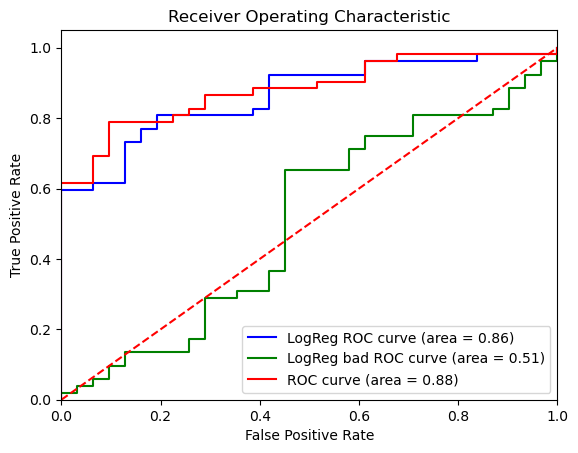

In [35]:
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy and recall
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")

# Calculate ROC curve and AUC
fpr_nn, tpr_nn, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)

# Plot ROC curve
plt.figure()
plt.plot(logreg['fpr'], logreg['tpr'], color='blue', label='LogReg ROC curve (area = {:.2f})'.format(logreg['roc_auc']))
plt.plot(logreg['fpr_reduced'], logreg['tpr_reduced'], color='green', label='LogReg bad ROC curve (area = {:.2f})'.format(logreg['roc_auc_reduced']))
plt.plot(fpr_nn, tpr_nn, color='red', label='ROC curve (area = {:.2f})'.format(roc_auc_nn))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()